# 03 – Noise Robustness: LSA vs One-Step Gradient Descent Under Label Noise

In **Notebook 01**, we showed that a one-layer Linear Self-Attention (LSA) model
can learn to imitate a single step of gradient descent (GD) on small synthetic
linear regression tasks.

In **Notebook 02**, we scaled up the problem size (larger `d` and `n`) and found
that LSA remains approximately GD-like, with gradually decreasing alignment.

In this notebook, we **build on the same setup** and ask a different question:

> How robust is the LSA model to **label noise** in the context examples, and how
> does this compare to a fixed one-step GD baseline?

Concretely:
- We keep the same synthetic linear regression task distribution.
- We fix `(d, n) = (10, 21)` (moderate scale).
- We add **Gaussian noise** to the *context labels* with different noise levels:
  - `noise_std` ∈ {0.0, 0.1, 0.2, 0.3}
- For each noise level, we train a fresh LSA model and compare it to one-step GD
  using:
  - Mean squared error (MSE) on the true (clean) query target.
  - Cosine similarity between LSA and GD predictions.


In [1]:
# Imports and setup (same libraries as in previous notebooks)

import math, torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(0)


## 1. Shared Setup (Reused from Base Experiment)

We keep the same high-level design as in Notebook 01:

- Synthetic linear regression tasks with a random "teacher" weight vector `W`.
- A **context set** of `(x_i, y_i)` pairs and a **query** pair `(x_q, y_q)`.
- A one-layer **Linear Self-Attention (LSA)** model that processes context + query
  tokens in a single forward pass.
- A **one-step gradient descent** baseline starting from `w = 0`.

The key change in this notebook is that we introduce **label noise** in the
context labels `Y`, while keeping the underlying regression relationship and
query target `y_q` clean. This lets us test how LSA and GD respond to noisy
supervision.


In [2]:
# 1. Task sampler: synthetic linear regression with optional label noise

class LinearTaskSampler:
    """
    Samples batches of simple linear regression tasks, with optional Gaussian
    noise added to the context labels.

    For each task:
    - Sample a ground-truth weight vector W of shape [B, out_dim, d].
    - Sample n context inputs X in [-x_range, x_range]^d.
    - Compute clean context targets Y_clean = X W^T.
    - Sample a query input x_q and its clean target y_q = x_q W^T.

    Noise is added only to the context labels (Y), not to x_q or y_q.
    """
    def __init__(self, d, n, batch_tasks, out_dim=1, x_range=1.0, device="cpu"):
        self.d, self.n, self.B = d, n, batch_tasks
        self.out_dim = out_dim
        self.x_range = x_range
        self.device = device

    def sample_batch(self, noise_std=0.0):
        B, d, n = self.B, self.d, self.n
        W = torch.randn(B, self.out_dim, d, device=self.device)
        X = (2*self.x_range)*torch.rand(B, n, d, device=self.device) - self.x_range
        Y_clean = torch.einsum("bnd, bod->bno", X, W)
        x_q = (2*self.x_range)*torch.rand(B, d, device=self.device) - self.x_range
        y_q = torch.einsum("bd, bod->bo", x_q, W)

        if noise_std > 0.0:
            noise = noise_std * torch.randn_like(Y_clean)
            Y_noisy = Y_clean + noise
        else:
            Y_noisy = Y_clean

        return X, Y_clean, Y_noisy, x_q, y_q, W

In [4]:
# 2. One-layer Linear Self-Attention model (same as before)

class LinearSelfAttention1L(nn.Module):
    """
    One-layer linear self-attention (single head, no softmax).

    Given a sequence of tokens (context + query), this layer:
    - Computes Q, K, V projections.
    - Forms attention logits via K Q^T (no softmax).
    - Aggregates values and applies a linear projection P.
    - Adds a residual connection to produce updated tokens.
    """
    def __init__(self, token_dim):
        super().__init__()
        D = token_dim
        self.W_Q = nn.Linear(D, D, bias=False)
        self.W_K = nn.Linear(D, D, bias=False)
        self.W_V = nn.Linear(D, D, bias=False)
        self.P   = nn.Linear(D, D, bias=False)

    def forward(self, tokens):
        Q = self.W_Q(tokens)
        K = self.W_K(tokens)
        V = self.W_V(tokens)
        att = torch.einsum("bid,bjd->bij", K, Q)
        val = torch.einsum("bij,bjd->bid", att, V)
        return tokens + self.P(val)

In [5]:
# 3. Helper functions: tokens, readout, and one-step GD baseline

def build_tokens(X, Y, x_q, out_dim=1):
    """
    Build token sequence for LSA model.

    Context tokens: [x_i, y_i] for each (possibly noisy) context point.
    Query token:    [x_q, 0] with the y-slot initialized to 0.

    Returns:
        tokens: [B, n_context + 1, d + out_dim]
    """
    B, n, d = X.shape
    y_q_init = torch.zeros(B, out_dim, device=X.device)
    ctx = torch.cat([X, Y], dim=-1)
    q = torch.cat([x_q, y_q_init], dim=-1).unsqueeze(1)
    return torch.cat([ctx, q], dim=1)

def readout(updated, out_dim=1):
    """
    Read out the predicted query y from the last token.
    Assumes the y-slot is stored in the last `out_dim` entries.
    """
    return updated[:, -1, -out_dim:]


In [6]:
def gd_one_step(X, Y, x_q, lr):
    """
    Compute a one-step gradient descent prediction for linear regression.

    Uses (possibly noisy) context labels Y to compute the gradient and takes
    one step from w_0 = 0, then evaluates at x_q.
    """
    B, n, d = X.shape
    delta = (lr/n) * (X * Y).sum(dim=1)
    return (delta * x_q).sum(dim=-1, keepdim=True)


## 2. Noise Levels and Training Setup

We fix the problem size to a moderate setting:

- Input dimension: `d = 10`
- Number of context points: `n = 21`

We then vary **label noise** in the context set using Gaussian noise with
standard deviation:

- `noise_std` ∈ {0.0, 0.1, 0.2, 0.3}

For each noise level, we:

1. Train a fresh one-layer LSA model on tasks where the context labels are
   corrupted by noise with the given `noise_std`.
2. Compare its performance to a fixed one-step GD baseline that sees the
   same noisy labels.
3. Evaluate both models on **clean query targets** `y_q` to measure how
   robust each method is to noisy supervision.


In [7]:
# 4. Noise experiment configuration

d, n = 10, 21
batch_tasks = 256
num_steps = 2000
gd_lr = 0.5

noise_levels = [0.0, 0.1, 0.2, 0.3]
results = {}


In [8]:
def run_noise_experiment(noise_std):
    """
    Train a one-layer LSA model on tasks with label noise of strength `noise_std`
    and compare it to a one-step GD baseline.

    Noise is applied only to the context labels (Y), not to the query targets.

    Returns:
        mse_lsa: MSE of LSA predictions on a fresh batch
        mse_gd:  MSE of GD baseline on the same batch
        cos_sim: cosine similarity between LSA and GD predictions
    """
    sampler = LinearTaskSampler(d=d, n=n, batch_tasks=batch_tasks, device=device)
    model = LinearSelfAttention1L(token_dim=d+1).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)

    for step in range(1, num_steps+1):
        X, Y_clean, Y_noisy, x_q, y_q, _ = sampler.sample_batch(noise_std=noise_std)
        X, Y_clean, Y_noisy = X.to(device), Y_clean.to(device), Y_noisy.to(device)
        x_q, y_q = x_q.to(device), y_q.to(device)

        tokens = build_tokens(X, Y_noisy, x_q)
        out = model(tokens)
        y_lsa = readout(out)

        with torch.no_grad():
            y_gd = gd_one_step(X, Y_noisy, x_q, lr=gd_lr)

        loss = F.mse_loss(y_lsa, y_q)
        opt.zero_grad()
        loss.backward()
        opt.step()

    X, Y_clean, Y_noisy, x_q, y_q, _ = sampler.sample_batch(noise_std=noise_std)
    X, Y_clean, Y_noisy = X.to(device), Y_clean.to(device), Y_noisy.to(device)
    x_q, y_q = x_q.to(device), y_q.to(device)

    y_lsa = readout(model(build_tokens(X, Y_noisy, x_q)))
    y_gd = gd_one_step(X, Y_noisy, x_q, gd_lr)

    mse_lsa = F.mse_loss(y_lsa, y_q).item()
    mse_gd  = F.mse_loss(y_gd,  y_q).item()
    cos_sim = F.cosine_similarity(y_lsa, y_gd).mean().item()

    return mse_lsa, mse_gd, cos_sim

In [9]:
# 5. Run noise experiments for all noise levels

for noise in noise_levels:
    mse_lsa, mse_gd, cos_sim = run_noise_experiment(noise)
    results[noise] = {
        "mse_lsa": mse_lsa,
        "mse_gd": mse_gd,
        "cos": cos_sim,
    }
    print(noise, results[noise])


0.0 {'mse_lsa': 1.0082767009735107, 'mse_gd': 2.3593640327453613, 'cos': 0.953125}
0.1 {'mse_lsa': 1.125199794769287, 'mse_gd': 2.367410182952881, 'cos': 0.953125}
0.2 {'mse_lsa': 1.0393708944320679, 'mse_gd': 2.3257360458374023, 'cos': 0.9453125}
0.3 {'mse_lsa': 1.1451717615127563, 'mse_gd': 2.6642117500305176, 'cos': 0.9453125}


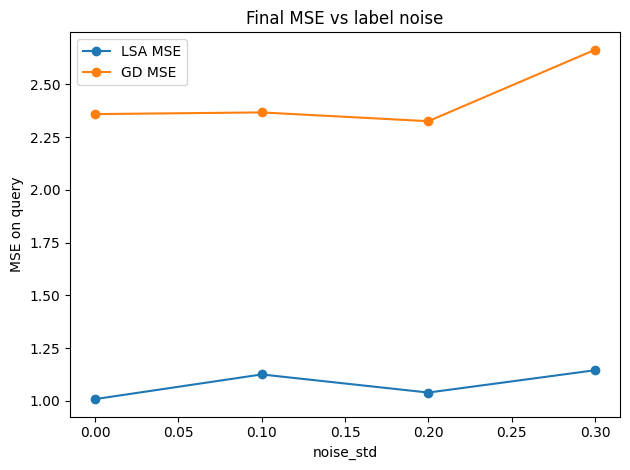

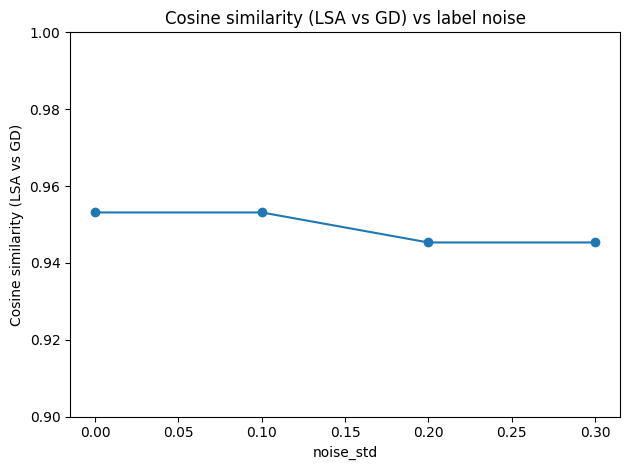

In [10]:
# 6. Visualizations: MSE and cosine similarity vs label noise


xs = noise_levels
mse_lsa_vals = [results[n]["mse_lsa"] for n in xs]
mse_gd_vals  = [results[n]["mse_gd"]  for n in xs]
cos_vals     = [results[n]["cos"]     for n in xs]

plt.figure()
plt.plot(xs, mse_lsa_vals, marker="o", label="LSA MSE")
plt.plot(xs, mse_gd_vals,  marker="o", label="GD MSE")
plt.xlabel("noise_std")
plt.ylabel("MSE on query")
plt.title("Final MSE vs label noise")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure()
plt.plot(xs, cos_vals, marker="o")
plt.xlabel("noise_std")
plt.ylabel("Cosine similarity (LSA vs GD)")
plt.title("Cosine similarity (LSA vs GD) vs label noise")
plt.ylim(0.9, 1.0)
plt.tight_layout()
plt.show()

## 3. Summary and Discussion

This notebook builds on the base LSA vs GD experiment by testing how both
methods respond to **label noise** in the context examples.

**Performance under noise.**  
Across all tested noise levels (`noise_std` up to 0.3), the LSA model maintains
a substantially lower MSE than the one-step GD baseline when evaluated on clean
query targets. This suggests that the LSA model learns an update rule that is robust to noisy supervision than a fixed gradient.

**Alignment with gradient descent.**  
Cosine similarity between LSA and GD predictions remains high (around 0.95) for
all noise levels, even as label noise increases. This indicates that LSA
continues to produce GD-like updates directionally, while adjusting its
magnitude or effective step size in a way that better accommodates noisy labels.

**Relation to previous notebooks.**  
- In Notebook 01, we saw that a one-layer LSA model can imitate one-step GD on
  clean, low-noise tasks.
- In Notebook 02, we observed that this correspondence persists under moderate
  scaling of problem size, with gradually decreasing alignment.
- Here, we find that the same architecture also exhibits **robustness to label
  noise**, continuing to behave like a learned, GD-inspired in-context optimizer
  that outperforms a fixed one-step update.

